In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import gc
from sklearn.metrics import classification_report

In [3]:
train_id = pd.read_csv('train_identity.csv')
train_transaction = pd.read_csv('train_transaction.csv')

print(f'Size of train_id - rows: {train_id.shape[0]}, columns: {train_id.shape[1]}')
print(f'Size of train_transaction - rows:{train_transaction.shape[0]}, columns: {train_transaction.shape[1]}')
# combine the data and work with the whole dataset
train = train_transaction.merge(train_id,on=['TransactionID'],how='left') 
print(f'Size of train - rows : {train.shape[0]}, columns : {train.shape[1]}')

train.shape

Size of train_id - rows: 144233, columns: 41
Size of train_transaction - rows:590540, columns: 394
Size of train - rows : 590540, columns : 434


(590540, 434)

In [4]:
train_GB = train.memory_usage(deep = True).sum()/1024**3 
print(f'train dataframe is using {train_GB:.2f} GB of memory storage')

train dataframe is using 2.51 GB of memory storage


In [5]:
del train_id
del train_transaction
gc.collect

<function gc.collect(generation=2)>

In [6]:
train=train.truncate(after=50000)
train.shape

(50001, 434)

In [7]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [8]:
def reduce_mem_usage(df):

    start_mem = df.memory_usage(index=True, deep=True).sum() / 1024**2
    start_mem_GB = df.memory_usage(index=True, deep=True).sum() / 1024**3
    print(f'Initial memory usage of dataframe is {start_mem:.2f} MB/{start_mem_GB:.2f} GB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage(index=True, deep=True).sum() / 1024**2
    end_mem_GB = df.memory_usage(index=True, deep=True).sum() / 1024**3
    reduction = 100 * (start_mem - end_mem) / start_mem
    print(f'Memory usage after optimization is: {end_mem:.2f} MB/{end_mem_GB:.2f} GB')
    print(f'Decreased by {reduction:.1f}%')
    
    return df


In [9]:
train = reduce_mem_usage(train)

Initial memory usage of dataframe is 217.88 MB/0.21 GB
Memory usage after optimization is: 42.87 MB/0.04 GB
Decreased by 80.3%


In [10]:
total_mv= train.isnull().sum().to_frame()                        #round to whole number 
percent_mv = (train.isnull().sum()/train.isnull().count()*100)   # round to 2 dp

pd.concat([total_mv, percent_mv], axis=1, keys=['Total Missing Values', 'Percent']).transpose()

,,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
Total Missing Values,0,0.0,0.0,0.0,0.0,0.0,0.0,697.000000,3.000,6.000,235.000000,...,33953.000000,38327.000000,39180.000000,38361.000000,33932.000000,33932.000000,33932.000000,33932.000000,33933.000000,35650.000000
Percent,0,0.0,0.0,0.0,0.0,0.0,0.0,1.393972,0.006,0.012,0.469991,...,67.904642,76.652467,78.358433,76.720466,67.862643,67.862643,67.862643,67.862643,67.864643,71.298574


In [13]:
target_count = train['isFraud'].value_counts()
target_percent = train['isFraud'].value_counts()/len(train)

print('Target Column : isFraud')
pd.concat([ target_count, target_percent], axis=1, keys=['Count', 'Percent'])

Target Column : isFraud


,Count,Percent
0,48644,0.972861
1,1357,0.027139


### Correlation Study - Numerical Features


In [15]:
cat_features = ['ProductCD','card4','card6', 'P_emaildomain', 'R_emaildomain',
                'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_15',
                'id_16','id_23','id_27','id_28','id_29','id_30','id_31',
                'id_33','id_34','id_35','id_36','id_37','id_38']

num_features = [x for x in train.columns.values[2:] if x not in cat_features]  #slicing from 2 onwards ( first 2 columns are identifier and target)

features = num_features + cat_features

print('Categorical features :', len(cat_features))
print('Numerical features : ',len(num_features))

Categorical features : 31
Numerical features :  401


### Encoding Categorical Features

In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
y=train['isFraud']

scaler = StandardScaler()

ohe = OneHotEncoder(handle_unknown='ignore')


column_trans = ColumnTransformer(
    [('ohe', ohe, cat_features)], remainder='passthrough', n_jobs=-1)
  


t = pd.DataFrame(column_trans.fit_transform(train,y))
train.head()
train=train.join(t)
train.shape

(50001, 1853)

In [18]:
### Scaling Numerical Features
scaler = StandardScaler()
train[num_features] = scaler.fit_transform(train[num_features])
print (train.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD     card1  \
0        2987000        0      -1.707454       -0.279863         W  0.818302   
1        2987001        0      -1.707451       -0.465249         W -1.459380   
2        2987002        0      -1.707240       -0.324449         W -1.070353   
3        2987003        0      -1.707148       -0.366689         W  1.675873   
4        2987004        0      -1.707126       -0.366689         H -1.104199   

      card2     card3       card4     card5  ...   1409  1410   1411   1412  \
0       NaN -0.267467    discover -1.456731  ...    NaN   NaN    NaN    NaN   
1  0.234914 -0.267467  mastercard -2.449320  ...    NaN   NaN    NaN    NaN   
2  0.775603 -0.267467        visa -0.861177  ...    NaN   NaN    NaN    NaN   
3  1.259709 -0.267467  mastercard -2.077099  ...    NaN   NaN    NaN    NaN   
4  0.926493 -0.267467  mastercard -2.449320  ...  166.0   NaN  542.0  144.0   

   1413 1414 1415  1416  1417  1418  
0   Na

In [19]:
del scaler, ohe, column_trans, t
gc.collect

<function gc.collect(generation=2)>

In [20]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,1409,1410,1411,1412,1413,1414,1415,1416,1417,1418
0,2987000,0,-1.707454,-0.279863,W,0.818302,NaN,-0.267467,discover,-1.456731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,-1.707451,-0.465249,W,-1.459380,0.234914,-0.267467,mastercard,-2.449320,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,-1.707240,-0.324449,W,-1.070353,0.775603,-0.267467,visa,-0.861177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,-1.707148,-0.366689,W,1.675873,1.259709,-0.267467,mastercard,-2.077099,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,-1.707126,-0.366689,H,-1.104199,0.926493,-0.267467,mastercard,-2.449320,...,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,32.0


In [21]:
train.drop(cat_features, axis=1, inplace=True)

print(train.shape)

(50001, 1822)


In [22]:
print(train.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt     card1     card2  \
0        2987000        0      -1.707454       -0.279863  0.818302       NaN   
1        2987001        0      -1.707451       -0.465249 -1.459380  0.234914   
2        2987002        0      -1.707240       -0.324449 -1.070353  0.775603   
3        2987003        0      -1.707148       -0.366689  1.675873  1.259709   
4        2987004        0      -1.707126       -0.366689 -1.104199  0.926493   

      card3     card5     addr1    addr2  ...   1409  1410   1411   1412  \
0 -0.267467 -1.456731  0.220847  0.21076  ...    NaN   NaN    NaN    NaN   
1 -0.267467 -2.449320  0.316093  0.21076  ...    NaN   NaN    NaN    NaN   
2 -0.267467 -0.861177  0.363717  0.21076  ...    NaN   NaN    NaN    NaN   
3 -0.267467 -2.077099  1.754318  0.21076  ...    NaN   NaN    NaN    NaN   
4 -0.267467 -2.449320  1.220936  0.21076  ...  166.0   NaN  542.0  144.0   

   1413  1414  1415  1416  1417  1418  
0   NaN   NaN   NaN   

   TransactionID  isFraud  TransactionDT  TransactionAmt     card1     card2  \
0        2987000        0      -1.707454       -0.279863  0.818302       NaN   
1        2987001        0      -1.707451       -0.465249 -1.459380  0.234914   
2        2987002        0      -1.707240       -0.324449 -1.070353  0.775603   
3        2987003        0      -1.707148       -0.366689  1.675873  1.259709   
4        2987004        0      -1.707126       -0.366689 -1.104199  0.926493   

      card3     card5     addr1    addr2  ...   1409  1410   1411   1412  \
0 -0.267467 -1.456731  0.220847  0.21076  ...    NaN   NaN    NaN    NaN   
1 -0.267467 -2.449320  0.316093  0.21076  ...    NaN   NaN    NaN    NaN   
2 -0.267467 -0.861177  0.363717  0.21076  ...    NaN   NaN    NaN    NaN   
3 -0.267467 -2.077099  1.754318  0.21076  ...    NaN   NaN    NaN    NaN   
4 -0.267467 -2.449320  1.220936  0.21076  ...  166.0   NaN  542.0  144.0   

   1413  1414  1415  1416  1417  1418  
0   NaN   NaN   NaN   

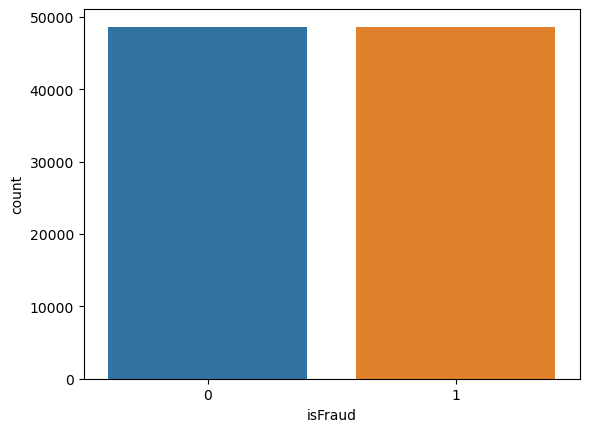

In [23]:
from sklearn.utils import resample
y=train['isFraud']
df_majority = train[y == 0]

df_minority = train[y == 1]
size_major = len(df_majority)

y_majority = y[y == 0]
y_minority = y[y == 1]

# Downsample majority class
df_minority_upsampled = resample(df_minority, 
                   replace=True,    # sample with replacement
                   n_samples=size_major,    # to match majority class
                   random_state=42)  # reproducible results

train = pd.concat([df_majority, df_minority_upsampled])
y_minority_upsampled = y_minority[df_minority_upsampled.index]
y = pd.concat([y_majority, y_minority_upsampled])

sns.countplot(x = y);
print(train.head(),y.head())
print(train.shape,y.shape)

In [24]:
del df_majority, df_minority, size_major, y_majority, y_minority, df_minority_upsampled, y_minority_upsampled, 
gc.collect

<function gc.collect(generation=2)>

In [41]:
train= train.rename(str,axis="columns") 


#imputer = SimpleImputer(strategy='median')
#imputer.fit(train)
#X_train = imputer.transform(train)
#print(X_train.shape)
#y.shape

In [42]:

imputer = SimpleImputer(strategy='median')
imputer.fit(train)
X_train = imputer.transform(train)
print(X_train.shape)
y.shape

(97288, 1820)


(97288,)

In [30]:
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


In [34]:
#pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/70/58/2f94976df39470fb00eec2cb4f914dde44cd0df8d96483208bf7db4bc97e/xgboost-2.1.3-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 1.2/124.9 MB 37.7 MB/s eta 0:00:04
    --------------------------------------- 2.8/124.9 MB 35.7 MB/s eta 0:00:04
   - -------------------------------------- 4.3/124.9 MB 34.2 MB/s eta 0:00:04
   -- ------------------------------------- 6.4/124.9 MB 37.3 MB/s eta 0:00:04
   -- ------------------------------------- 8.9/124.9 MB 40.6 MB/s eta 0:00:03
   --- ------------------------------------ 11.4/124.9 MB 46.7 MB/s eta 0:00:03
   ---- ----------------------------------- 13.6/124.9 MB 46.9 MB/s eta 0:00:03
   ----- ---------------------------------- 15.6/124.9 MB 46.9 MB/s eta 0:00:03
   ----- ---------------------------------- 17.8/124.9 MB 43.5 MB/s eta 0:00:03
   ------

In [35]:
from xgboost import XGBClassifier

In [36]:
y=train['isFraud']
train.drop("isFraud", axis=1, inplace=True)
train.drop("TransactionID", axis=1, inplace=True)

In [43]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X_train, y,test_size=0.3, stratify=y)

In [44]:
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
for i in range (1,10,2):
  neigh = KNeighborsClassifier(n_neighbors=i)
  # neigh.fit(X_train, Y_train)
  neigh.fit(train_X,train_y)
  predict = neigh.predict(test_X)
  print("classification report of k= ", i)
  print(classification_report(predict,test_y))

classification report of k=  1
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     14183
           1       1.00      0.97      0.99     15004

    accuracy                           0.99     29187
   macro avg       0.99      0.99      0.99     29187
weighted avg       0.99      0.99      0.99     29187

classification report of k=  3
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     13754
           1       1.00      0.95      0.97     15433

    accuracy                           0.97     29187
   macro avg       0.97      0.97      0.97     29187
weighted avg       0.97      0.97      0.97     29187

classification report of k=  5
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     13403
           1       1.00      0.92      0.96     15784

    accuracy                           0.96     29187
   macro avg       0.96      0.96  

In [46]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

# Fit the model
nb.fit(train_X, train_y)

# Print the accuracy score
print("Accuracy:",nb.score(test_X, test_y))
y_pred = nb.predict(test_X)

cr = classification_report(test_y, y_pred)
print("\n\nClassification Report\n")
print(cr)

Accuracy: 0.6170212765957447


Classification Report

              precision    recall  f1-score   support

           0       0.74      0.36      0.48     14593
           1       0.58      0.87      0.70     14594

    accuracy                           0.62     29187
   macro avg       0.66      0.62      0.59     29187
weighted avg       0.66      0.62      0.59     29187



In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
clf_rf_down = RandomForestClassifier(random_state=42)
model_rf_down = clf_rf_down.fit(train_X, train_y)
y_pred = model_rf_down.predict(test_X)
cr = classification_report(test_y, y_pred)
print("\n\nClassification Report\n")
print(cr)



Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14593
           1       1.00      1.00      1.00     14594

    accuracy                           1.00     29187
   macro avg       1.00      1.00      1.00     29187
weighted avg       1.00      1.00      1.00     29187



In [48]:
from xgboost import XGBClassifier
XGB_model = XGBClassifier(seed=42,
                      n_estimators=500,
                      max_depth=10,
                      learning_rate=0.2)

# model.fit(X_train, y_train)
model_xgb_down = XGB_model.fit(train_X, train_y)
# y_prob = .predict_proba(test_X)[:, 1]
y_pred = model_xgb_down.predict(test_X)

cr = classification_report(test_y, y_pred)
print("\n\nClassification Report\n")
print(cr)



Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14593
           1       1.00      1.00      1.00     14594

    accuracy                           1.00     29187
   macro avg       1.00      1.00      1.00     29187
weighted avg       1.00      1.00      1.00     29187



In [49]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=1e20)
model.fit(train_X, train_y)
preds = model.predict(test_X)
cr = classification_report(test_y, preds)
print("\n\nClassification Report\n")
print(cr)



Classification Report

              precision    recall  f1-score   support

           0       0.61      0.66      0.64     14593
           1       0.63      0.58      0.61     14594

    accuracy                           0.62     29187
   macro avg       0.62      0.62      0.62     29187
weighted avg       0.62      0.62      0.62     29187



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
